<a href="https://colab.research.google.com/github/Priya-Kumari-Chourasia/ml_algo/blob/main/k_means_clustering_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

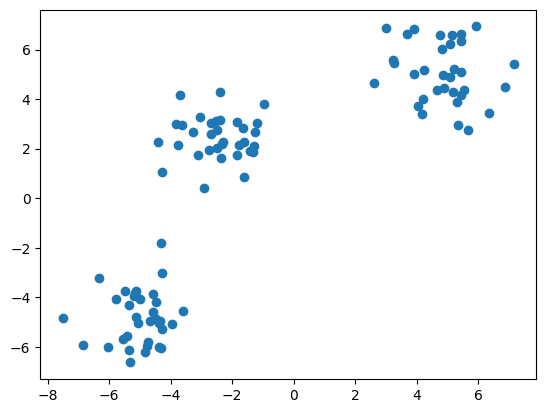

In [11]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

centroids = [(-5,-5),(5,5),(-2.5,2.5)]
cluster_std = [1,1,1]

X,y = make_blobs(n_samples=100,cluster_std =cluster_std,centers=centroids,n_features=2,random_state=23)

plt.scatter(X[:,0],X[:,1])
plt.show()

In [8]:
import random
import numpy as np
class KMeans:
  def __init__(self,n_clusters=2,max_iter=100):
    self.n_clusters = n_clusters
    self.max_iter = max_iter
    self.centroids = None

  def fit_predict(self,X):
    random_index = random.sample(range(0,X.shape[0]),self.n_clusters)
    self.centroids = X[random_index]

    for i in range(self.max_iter):
      cluster_group = self.assign_clusters(X)
      old_centroids = self.centroids
      self.centroids = self.move_centroids(X,cluster_group)
      # check finish
      if(old_centroids == self.centroids).all():
        break

    return cluster_group

  def assign_clusters(self,X):
    cluster_group = []
    distances = []

    for row in X:

      for centroid in self.centroids:
        distances.append(np.sqrt(np.dot(row-centroid,row-centroid)))
      min_distance = min(distances)
      index_pos = distances.index(min_distance)
      cluster_group.append(index_pos)

      #min_index = np.argmin(distances)
      distances.clear()

    return np.array(cluster_group)

  def move_centroids(self,X,cluster_group):
    new_centroids = []

    cluster_type = np.unique(cluster_group)

    for type in cluster_type:
      new_centroids.append(X[cluster_group == type].mean(axis=0))

    return np.array(new_centroids)





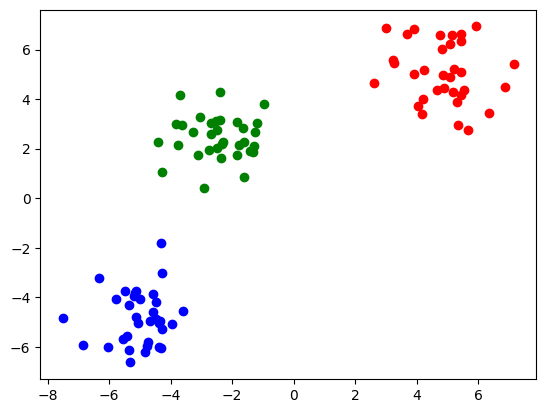

In [12]:
km = KMeans(n_clusters=3, max_iter=100)
y_means = km.fit_predict(X)

plt.scatter(X[y_means == 0,0],X[y_means == 0,1],color='red')
plt.scatter(X[y_means == 1,0],X[y_means == 1,1],color='blue')
plt.scatter(X[y_means == 2,0],X[y_means == 2,1],color='green')
plt.show()

In [13]:
import random
import numpy as np

class KMeans:
    def __init__(self, n_clusters=2, max_iter=100):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None
        self.wcss = 0

    def fit_predict(self, X):
        random_index = random.sample(range(0, X.shape[0]), self.n_clusters)
        self.centroids = X[random_index]

        for i in range(self.max_iter):
            cluster_group = self.assign_clusters(X)
            old_centroids = self.centroids
            self.centroids = self.move_centroids(X, cluster_group)

            if (old_centroids == self.centroids).all():
                break

        # Calculate WCSS (sum of squared distances from points to their assigned centroid)
        self.wcss = 0
        for k in range(self.n_clusters):
            points_in_cluster = X[cluster_group == k]
            if len(points_in_cluster) > 0:
                self.wcss += np.sum((points_in_cluster - self.centroids[k]) ** 2)

        return cluster_group

    def assign_clusters(self, X):
        cluster_group = []
        for row in X:
            distances = []
            for centroid in self.centroids:
                distances.append(np.sqrt(np.dot(row - centroid, row - centroid)))

            cluster_group.append(np.argmin(distances))

        return np.array(cluster_group)

    def move_centroids(self, X, cluster_group):
        new_centroids = []
        for k in range(self.n_clusters):
            points_in_cluster = X[cluster_group == k]
            if len(points_in_cluster) > 0:
                new_centroids.append(points_in_cluster.mean(axis=0))
            else:
                new_centroids.append(self.centroids[k])
        return np.array(new_centroids)

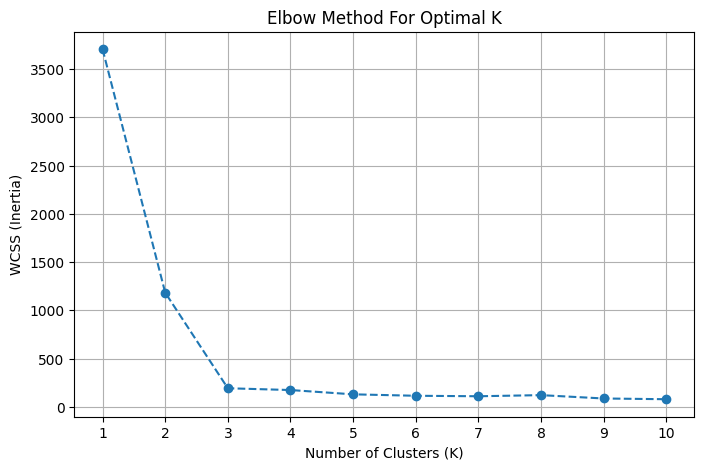

In [14]:
wcss_list = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, max_iter=100)
    km.fit_predict(X)
    wcss_list.append(km.wcss)

# Plotting the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss_list, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

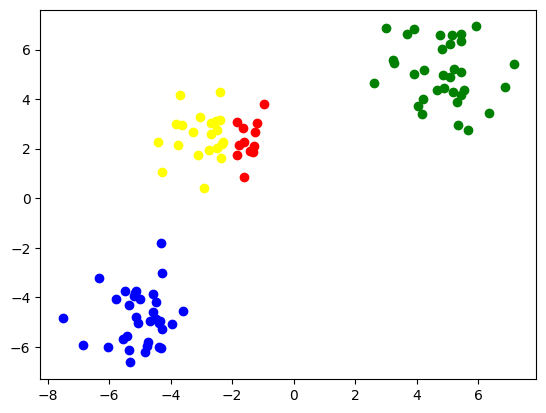

In [19]:
km = KMeans(n_clusters=4, max_iter=100)
y_means = km.fit_predict(X)

plt.scatter(X[y_means == 0,0],X[y_means == 0,1],color='red')
plt.scatter(X[y_means == 1,0],X[y_means == 1,1],color='blue')
plt.scatter(X[y_means == 2,0],X[y_means == 2,1],color='green')
plt.scatter(X[y_means == 3,0],X[y_means == 3,1],color='yellow')

plt.show()